# control vs. simulated node depths
#### may 2026

#### import modules

In [3]:
import os

In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
from matplotlib.colors import TwoSlopeNorm
import matplotlib.ticker as ticker

from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 

import itertools
from itertools import combinations

from Bio import SeqIO, AlignIO

import shutil

import warnings

# read in dfs

In [66]:
all = pd.read_csv('../../../migration/sweep/control/ctrl/scores_ctrl_full.csv')

/loc/scratch/51884484/ipykernel_28319/1542281145.py:1: DtypeWarning: Columns (7,20) have mixed types. Specify dtype option on import or set low_memory=False.
  all = pd.read_csv('../../../migration/sweep/control/ctrl/scores_ctrl_full.csv')


In [67]:
all = all.drop(columns=['Unnamed: 0','mrca_population', 'ctrl_node', 'ctrl_population', 'X1',
       'X2', 'X3', 'certainty', 'model','costfunction','node_state', 'rep1',
       'rep2', 'rep3', 'rep4', 'rep5', 'rep6', 'rep7', 'rep8', 'rep9', 'rep10',
       'mode'])

all.loc[~all['gaia_target'].isin(['sim', 'control']), 'gaia_target'] = 'inf'

all

,sample_a,sample_b,bin,position,node,ctrl_height,score,pm,mu,mr,seed,gaia_target,node_time,node_height_sim
0,19,27,0,50000,34,2627.6,1,0.100,2.500000e-08,0.00010,37,control,NaN,NaN
1,20,26,0,50000,35,1189.2,1,0.100,2.500000e-08,0.00010,37,control,NaN,NaN
2,22,24,0,50000,36,1189.2,1,0.100,2.500000e-08,0.00010,37,control,NaN,NaN
3,15,18,0,50000,37,2627.6,1,0.100,2.500000e-08,0.00010,37,control,NaN,NaN
4,28,30,0,50000,38,6293.2,1,0.100,2.500000e-08,0.00010,37,control,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191845,4,6,29,2950000,68,NaN,1,0.005,2.500000e-08,0.00005,73,inf,3326.463203,3379.411472
191846,4,10,29,2950000,68,NaN,1,0.005,2.500000e-08,0.00005,73,inf,3326.463203,3379.411472
191847,3,9,29,2950000,74,NaN,1,0.005,2.500000e-08,0.00005,73,inf,7595.472396,11155.389794
191848,8,20,29,2950000,79,NaN,0,0.005,2.500000e-08,0.00005,73,inf,47623.495581,20154.352850


In [68]:
all.columns

Index(['sample_a', 'sample_b', 'bin', 'position', 'node', 'ctrl_height',
       'score', 'pm', 'mu', 'mr', 'seed', 'gaia_target', 'node_time',
       'node_height_sim'],
      dtype='object')

In [77]:
ctrl = all[all['gaia_target'] == 'control']
sim = all[all['gaia_target'] == 'sim'].drop(columns = ['ctrl_height'])
inf = all[all['gaia_target'] == 'inf'].drop(columns = ['ctrl_height'])

In [79]:
ctrl = ctrl.drop(columns = ['node_time', 'node_height_sim'])
ctrl = ctrl.rename(columns={'ctrl_height': 'node_time'})
sim['node_height_sim'] = sim['node_time'] 

In [80]:
ctrl = pd.merge(
    ctrl, 
    sim[['node_height_sim', 'sample_a', 'sample_b', 'bin', 'position', 'node', 'pm', 'mu', 'mr', 'seed']], 
    on=[ 'sample_a', 'sample_b', 'bin', 'position', 'node', 'pm', 'mu', 'mr', 'seed'], 
    how='left'
)

In [84]:
merge = pd.concat([ctrl, inf], ignore_index=True)
merge

,sample_a,sample_b,bin,position,node,node_time,score,pm,mu,mr,seed,gaia_target,node_height_sim
0,19,27,0,50000,34,2627.600000,1,0.100,2.500000e-08,0.00010,37,control,1.199624
1,20,26,0,50000,35,1189.200000,1,0.100,2.500000e-08,0.00010,37,control,1.652826
2,22,24,0,50000,36,1189.200000,1,0.100,2.500000e-08,0.00010,37,control,4.700360
3,15,18,0,50000,37,2627.600000,1,0.100,2.500000e-08,0.00010,37,control,6.210399
4,28,30,0,50000,38,6293.200000,1,0.100,2.500000e-08,0.00010,37,control,8.427601
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127895,4,6,29,2950000,68,3326.463203,1,0.005,2.500000e-08,0.00005,73,inf,3379.411472
127896,4,10,29,2950000,68,3326.463203,1,0.005,2.500000e-08,0.00005,73,inf,3379.411472
127897,3,9,29,2950000,74,7595.472396,1,0.005,2.500000e-08,0.00005,73,inf,11155.389794
127898,8,20,29,2950000,79,47623.495581,0,0.005,2.500000e-08,0.00005,73,inf,20154.352850


## linear regression on node time 

In [86]:
def r2_log1p(x, y):
    x = np.log1p(x)
    y = np.log1p(y)
    r = np.corrcoef(x, y)[0, 1]

    return r**2

def r2_by_bin(merged):
    return (
        merged
        .groupby("bin", sort=False)
        .apply(lambda group: r2_log1p(group["node_time"], group["node_height_sim"]))
        .dropna()
    )

In [94]:
df = merge 

In [88]:
# grouped_r2 = (
#     merge.groupby(['seed', 'pm', 'mr', 'gaia_target'], sort=False)
#     .apply(r2_by_bin)
# )

# r2_vals = grouped_r2.to_numpy()

In [95]:
r2_results = df.groupby(['seed', 'pm', 'mr', 'gaia_target', 'bin']).apply(
    lambda g: r2_log1p(g['node_time'], g['node_height_sim'])
)

df['r2'] = df.set_index(['seed', 'pm', 'mr', 'gaia_target', 'bin']).index.map(r2_results)

In [96]:
df

,sample_a,sample_b,bin,position,node,node_time,score,pm,mu,mr,seed,gaia_target,node_height_sim,r2_value,r2
0,19,27,0,50000,34,2627.600000,1,0.100,2.500000e-08,0.00010,37,control,1.199624,0.946379,0.946379
1,20,26,0,50000,35,1189.200000,1,0.100,2.500000e-08,0.00010,37,control,1.652826,0.946379,0.946379
2,22,24,0,50000,36,1189.200000,1,0.100,2.500000e-08,0.00010,37,control,4.700360,0.946379,0.946379
3,15,18,0,50000,37,2627.600000,1,0.100,2.500000e-08,0.00010,37,control,6.210399,0.946379,0.946379
4,28,30,0,50000,38,6293.200000,1,0.100,2.500000e-08,0.00010,37,control,8.427601,0.946379,0.946379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127895,4,6,29,2950000,68,3326.463203,1,0.005,2.500000e-08,0.00005,73,inf,3379.411472,0.983879,0.983879
127896,4,10,29,2950000,68,3326.463203,1,0.005,2.500000e-08,0.00005,73,inf,3379.411472,0.983879,0.983879
127897,3,9,29,2950000,74,7595.472396,1,0.005,2.500000e-08,0.00005,73,inf,11155.389794,0.983879,0.983879
127898,8,20,29,2950000,79,47623.495581,0,0.005,2.500000e-08,0.00005,73,inf,20154.352850,0.983879,0.983879


## medians r2 agg by pm/mr

In [97]:
df['pm'].unique()

array([0.1  , 0.01 , 0.001, 0.3  , 0.05 , 0.005])

In [108]:
df['mr'].unique()

array([1.e-04, 1.e-05, 5.e-03, 5.e-04, 5.e-05])

In [122]:
df['rr'] = df['pm'] * 2.5e-8

In [123]:
inf_s = df[df['gaia_target'] == 'inf'] 
ctrl_s = df[df['gaia_target'] == 'control'] 

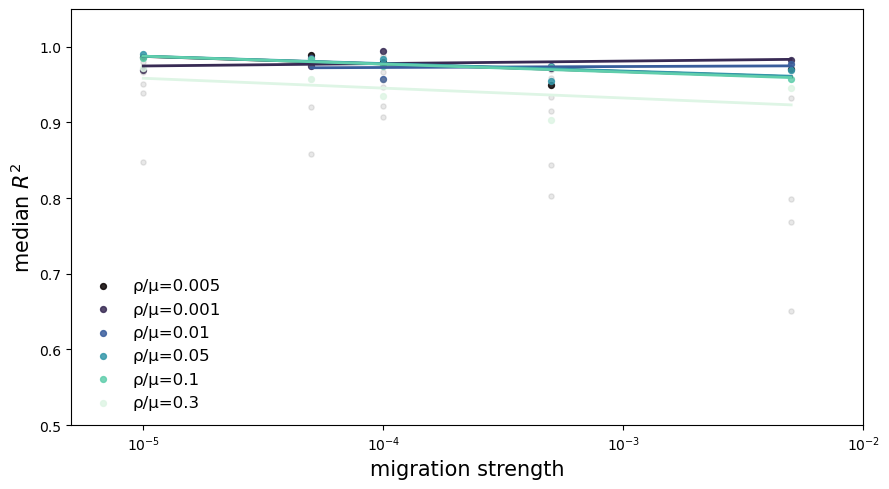

In [107]:
fig, ax = plt.subplots(figsize=(9, 5))

# colormap for different pm values
cmap = plt.get_cmap("mako")
pm_values = [0.005, 0.001, 0.01, 0.05, 0.1, 0.3]
colors = cmap(np.linspace(0, 1, len(pm_values)))

# aggregate so theres 1 row per (pm, rr) combo
inf_fit = (inf_s.groupby(["pm", "mr"], as_index=False).agg(median_r2=("r2", "median")))

null_fit = (ctrl_s.groupby(["pm", "mr"], as_index=False).agg(median_r2=("r2", "median")))

# plot per pm 
for pm, color in zip(pm_values, colors):
    # inferred
    sub_i = inf_fit[np.isclose(inf_fit["pm"], pm)]
    if len(sub_i):
        ax.scatter(
            sub_i["mr"], sub_i["median_r2"],
            s=18, alpha=0.85, color=color,
            label=f"ρ/μ={pm:g}"
        )
        if len(sub_i) >= 2:
            lx = np.log(sub_i["mr"].to_numpy())
            y = sub_i["median_r2"].to_numpy()
            m, b = np.polyfit(lx, y, 1)
            log_x = np.linspace(lx.min(), lx.max(), 200)
            ax.plot(np.exp(log_x), m * log_x + b, color=color, lw=2)

    # null (same color, lower alpha)
    sub_n = null_fit[np.isclose(null_fit["pm"], pm)]
    if len(sub_n):
        ax.scatter(
            sub_n["mr"], sub_n["median_r2"],
            s=14, alpha=0.18, color='grey'#,
           # label=f"null ρ/μ={pm:g}"
        )

    # if len(null_all):
    #     ax.scatter(
    #         null_s["rr"], null_s["median_r2"],
    #         s=12, alpha=0.75, c="lightgrey", label="null (permuted bins)"
    #     )
        # if len(sub_n) >= 2:
        #     lx = np.log(sub_n["rr"].to_numpy())
        #     y = sub_n["median_r2"].to_numpy()
        #     m, b = np.polyfit(lx, y, 1)
        #     log_x = np.linspace(lx.min(), lx.max(), 200)
        #     ax.plot(np.exp(log_x), m * log_x + b, color=color, lw=1, ls="--", alpha=0.35)

# fmt axes
ax.set_xscale("log")
ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.set_ylim(0.5, 1.05)

# x limits from inferred, else use null
all_rr = inf_fit["mr"] if len(inf_fit) else null_fit["mr"]
ax.set_xlim(all_rr.min() * 0.5, all_rr.max() * 2.0)

ax.set_xlabel("migration strength", fontsize=15)
ax.set_ylabel("median $R^2$", fontsize=15)


ax.legend(frameon=False, fontsize=12, loc="lower left", ncol=1)

fig.tight_layout()
#plt.savefig("rr_accuracy_single_bp_wide.png")
plt.show()


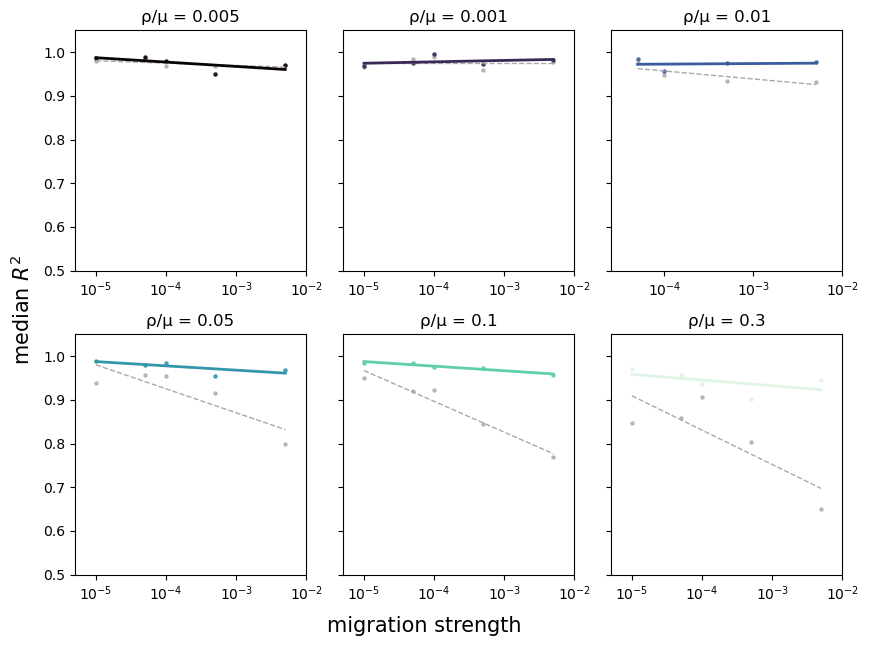

In [114]:
xlims = [(7e-14, 5e-6)] * len(pm_values)

fig, axes = plt.subplots(2, 3, figsize=(9, 7), sharex=False, sharey=True)

for ax, pm, color, xlim in zip(axes.flatten(), pm_values, colors, xlims):

    # subset by category (inf/null) 
    inf_sub = inf_fit[inf_fit["pm"] == pm]
    null_sub = null_fit[null_fit["pm"] == pm]

    # plot null
    if len(null_sub):
        ax.scatter(
            null_sub["mr"], null_sub["median_r2"],
            s=5, alpha=0.75, color="darkgrey", label="null"
        )
        if len(null_sub) >= 2:
            m_null, b_null = np.polyfit(np.log(null_sub["mr"]), null_sub["median_r2"], 1)
            log_x_null = np.linspace(
                np.log(null_sub["mr"]).min(),
                np.log(null_sub["mr"]).max(),
                200
            )
            ax.plot(
                np.exp(log_x_null),
                m_null * log_x_null + b_null,
                color="darkgrey", linestyle="--", lw=1
            )

    # plot inf
    if len(inf_sub):
        ax.scatter(
            inf_sub["mr"], inf_sub["median_r2"],
            s=5, alpha=0.85, color=color, label="inferred"
        )
        if len(inf_sub) >= 2:
            m_inf, b_inf = np.polyfit(np.log(inf_sub["mr"]), inf_sub["median_r2"], 1)
            log_x_inf = np.linspace(
                np.log(inf_sub["mr"]).min(),
                np.log(inf_sub["mr"]).max(),
                200
            )
            ax.plot(
                np.exp(log_x_inf),
                m_inf * log_x_inf + b_inf,
                color=color, lw=2, label="fit"
            )

        # x lims
        xmin = inf_sub["mr"].min()
        xmax = inf_sub["mr"].max()
        ax.set_xlim(xmin * 0.5, xmax * 2.0)

    else:
        ax.set_xlim(xlim)

    # fmt
    ax.set_xscale("log")
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.set_ylim(0.5, 1.05)
    ax.set_title(f"ρ/μ = {pm:g}")
    # ax.legend(frameon=True, fontsize=8, loc="lower left")

# shared labels
fig.text(0.5, 0.04, "migration strength", ha="center", fontsize=15)
fig.text(0.04, 0.5, "median $R^2$", va="center", rotation="vertical", fontsize=15)
#fig.text(0.5, 1.0, "single rep")


plt.tight_layout(rect=[0.06, 0.06, 1, 0.95])

#plt.savefig("median_rr_accuracy_facet_single.png")
plt.show()


In [119]:
inf_fit['rr'] = inf_fit['pm'] * 2.5e-8
null_fit['rr'] = null_fit['pm'] * 2.5e-8

/loc/scratch/51884484/ipykernel_28319/2100599165.py:26: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(lx, y, 1)
/loc/scratch/51884484/ipykernel_28319/2100599165.py:26: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(lx, y, 1)
/loc/scratch/51884484/ipykernel_28319/2100599165.py:26: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(lx, y, 1)
/loc/scratch/51884484/ipykernel_28319/2100599165.py:26: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(lx, y, 1)


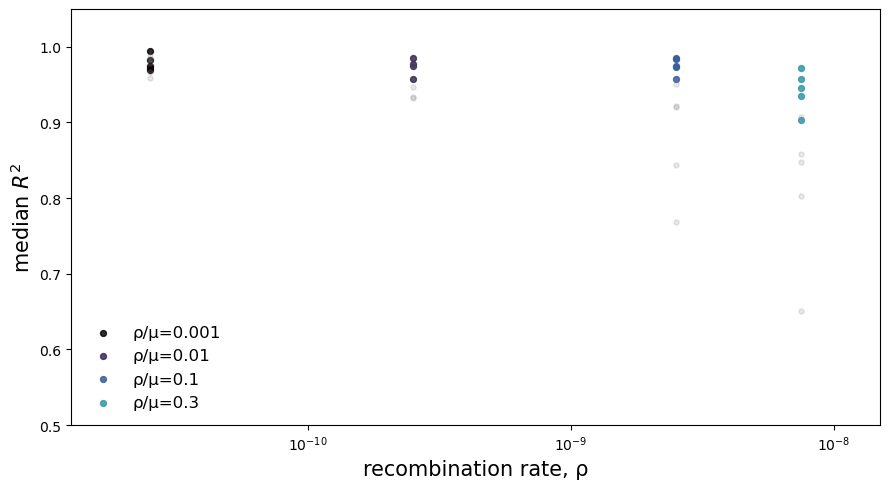

In [129]:
fig, ax = plt.subplots(figsize=(9, 5))

# colormap for different pm values
cmap = plt.get_cmap("mako")
pm_values = [0.001, 0.01, 0.1, 0.3, 1.0, 3.0]
colors = cmap(np.linspace(0, 1, len(pm_values)))

# aggregate so theres 1 row per (pm, rr) combo
inf_fit = (inf_s.groupby(["pm", "rr", 'mr'], as_index=False).agg(median_r2=("r2", "median")))

null_fit = (ctrl_s.groupby(["pm", "rr", 'mr'], as_index=False).agg(median_r2=("r2", "median")))

# plot per pm 
for pm, color in zip(pm_values, colors):
    # inferred
    sub_i = inf_fit[np.isclose(inf_fit["pm"], pm)]
    if len(sub_i):
        ax.scatter(
            sub_i["rr"], sub_i["median_r2"],
            s=18, alpha=0.85, color=color,
            label=f"ρ/μ={pm:g}"
        )
        if len(sub_i) >= 2:
            lx = np.log(sub_i["rr"].to_numpy())
            y = sub_i["median_r2"].to_numpy()
            m, b = np.polyfit(lx, y, 1)
            log_x = np.linspace(lx.min(), lx.max(), 200)
            ax.plot(np.exp(log_x), m * log_x + b, color=color, lw=2)

    # null (same color, lower alpha)
    sub_n = null_fit[np.isclose(null_fit["pm"], pm)]
    if len(sub_n):
        ax.scatter(
            sub_n["rr"], sub_n["median_r2"],
            s=14, alpha=0.18, color='grey'#,
           # label=f"null ρ/μ={pm:g}"
        )

    # if len(null_all):
    #     ax.scatter(
    #         null_s["rr"], null_s["median_r2"],
    #         s=12, alpha=0.75, c="lightgrey", label="null (permuted bins)"
    #     )
        # if len(sub_n) >= 2:
        #     lx = np.log(sub_n["rr"].to_numpy())
        #     y = sub_n["median_r2"].to_numpy()
        #     m, b = np.polyfit(lx, y, 1)
        #     log_x = np.linspace(lx.min(), lx.max(), 200)
        #     ax.plot(np.exp(log_x), m * log_x + b, color=color, lw=1, ls="--", alpha=0.35)

# fmt axes
ax.set_xscale("log")
ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.set_ylim(0.5, 1.05)

# x limits from inferred, else use null
all_rr = inf_fit["rr"] if len(inf_fit) else null_fit["rr"]
ax.set_xlim(all_rr.min() * 0.5, all_rr.max() * 2.0)

ax.set_xlabel("recombination rate, ρ", fontsize=15)
ax.set_ylabel("median $R^2$", fontsize=15)


ax.legend(frameon=False, fontsize=12, loc="lower left", ncol=1)

fig.tight_layout()
#plt.savefig("rr_accuracy_single_bp_wide.png")
plt.show()


In [127]:
inf_fit

,pm,rr,median_r2
0,0.001,2.500000e-11,0.994471
1,0.005,1.250000e-10,0.979608
2,0.010,2.500000e-10,0.975709
3,0.050,1.250000e-09,0.978077
4,0.100,2.500000e-09,0.975022
5,0.300,7.500000e-09,0.938435


## ctrl_height vs. sim_height

In [130]:
ctrl_s

,sample_a,sample_b,bin,position,node,node_time,score,pm,mu,mr,seed,gaia_target,node_height_sim,r2_value,r2,rr
0,19,27,0,50000,34,2627.6,1,0.100,2.500000e-08,0.00010,37,control,1.199624,0.946379,0.946379,2.500000e-09
1,20,26,0,50000,35,1189.2,1,0.100,2.500000e-08,0.00010,37,control,1.652826,0.946379,0.946379,2.500000e-09
2,22,24,0,50000,36,1189.2,1,0.100,2.500000e-08,0.00010,37,control,4.700360,0.946379,0.946379,2.500000e-09
3,15,18,0,50000,37,2627.6,1,0.100,2.500000e-08,0.00010,37,control,6.210399,0.946379,0.946379,2.500000e-09
4,28,30,0,50000,38,6293.2,1,0.100,2.500000e-08,0.00010,37,control,8.427601,0.946379,0.946379,2.500000e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63945,4,6,29,2950000,71,1090201.2,1,0.005,2.500000e-08,0.00005,73,control,3379.411472,0.973763,0.973763,1.250000e-10
63946,4,10,29,2950000,71,1090201.2,1,0.005,2.500000e-08,0.00005,73,control,3379.411472,0.973763,0.973763,1.250000e-10
63947,3,9,29,2950000,77,2229500.4,1,0.005,2.500000e-08,0.00005,73,control,11155.389794,0.973763,0.973763,1.250000e-10
63948,8,20,29,2950000,79,22549264.6,0,0.005,2.500000e-08,0.00005,73,control,20154.352850,0.973763,0.973763,1.250000e-10


/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


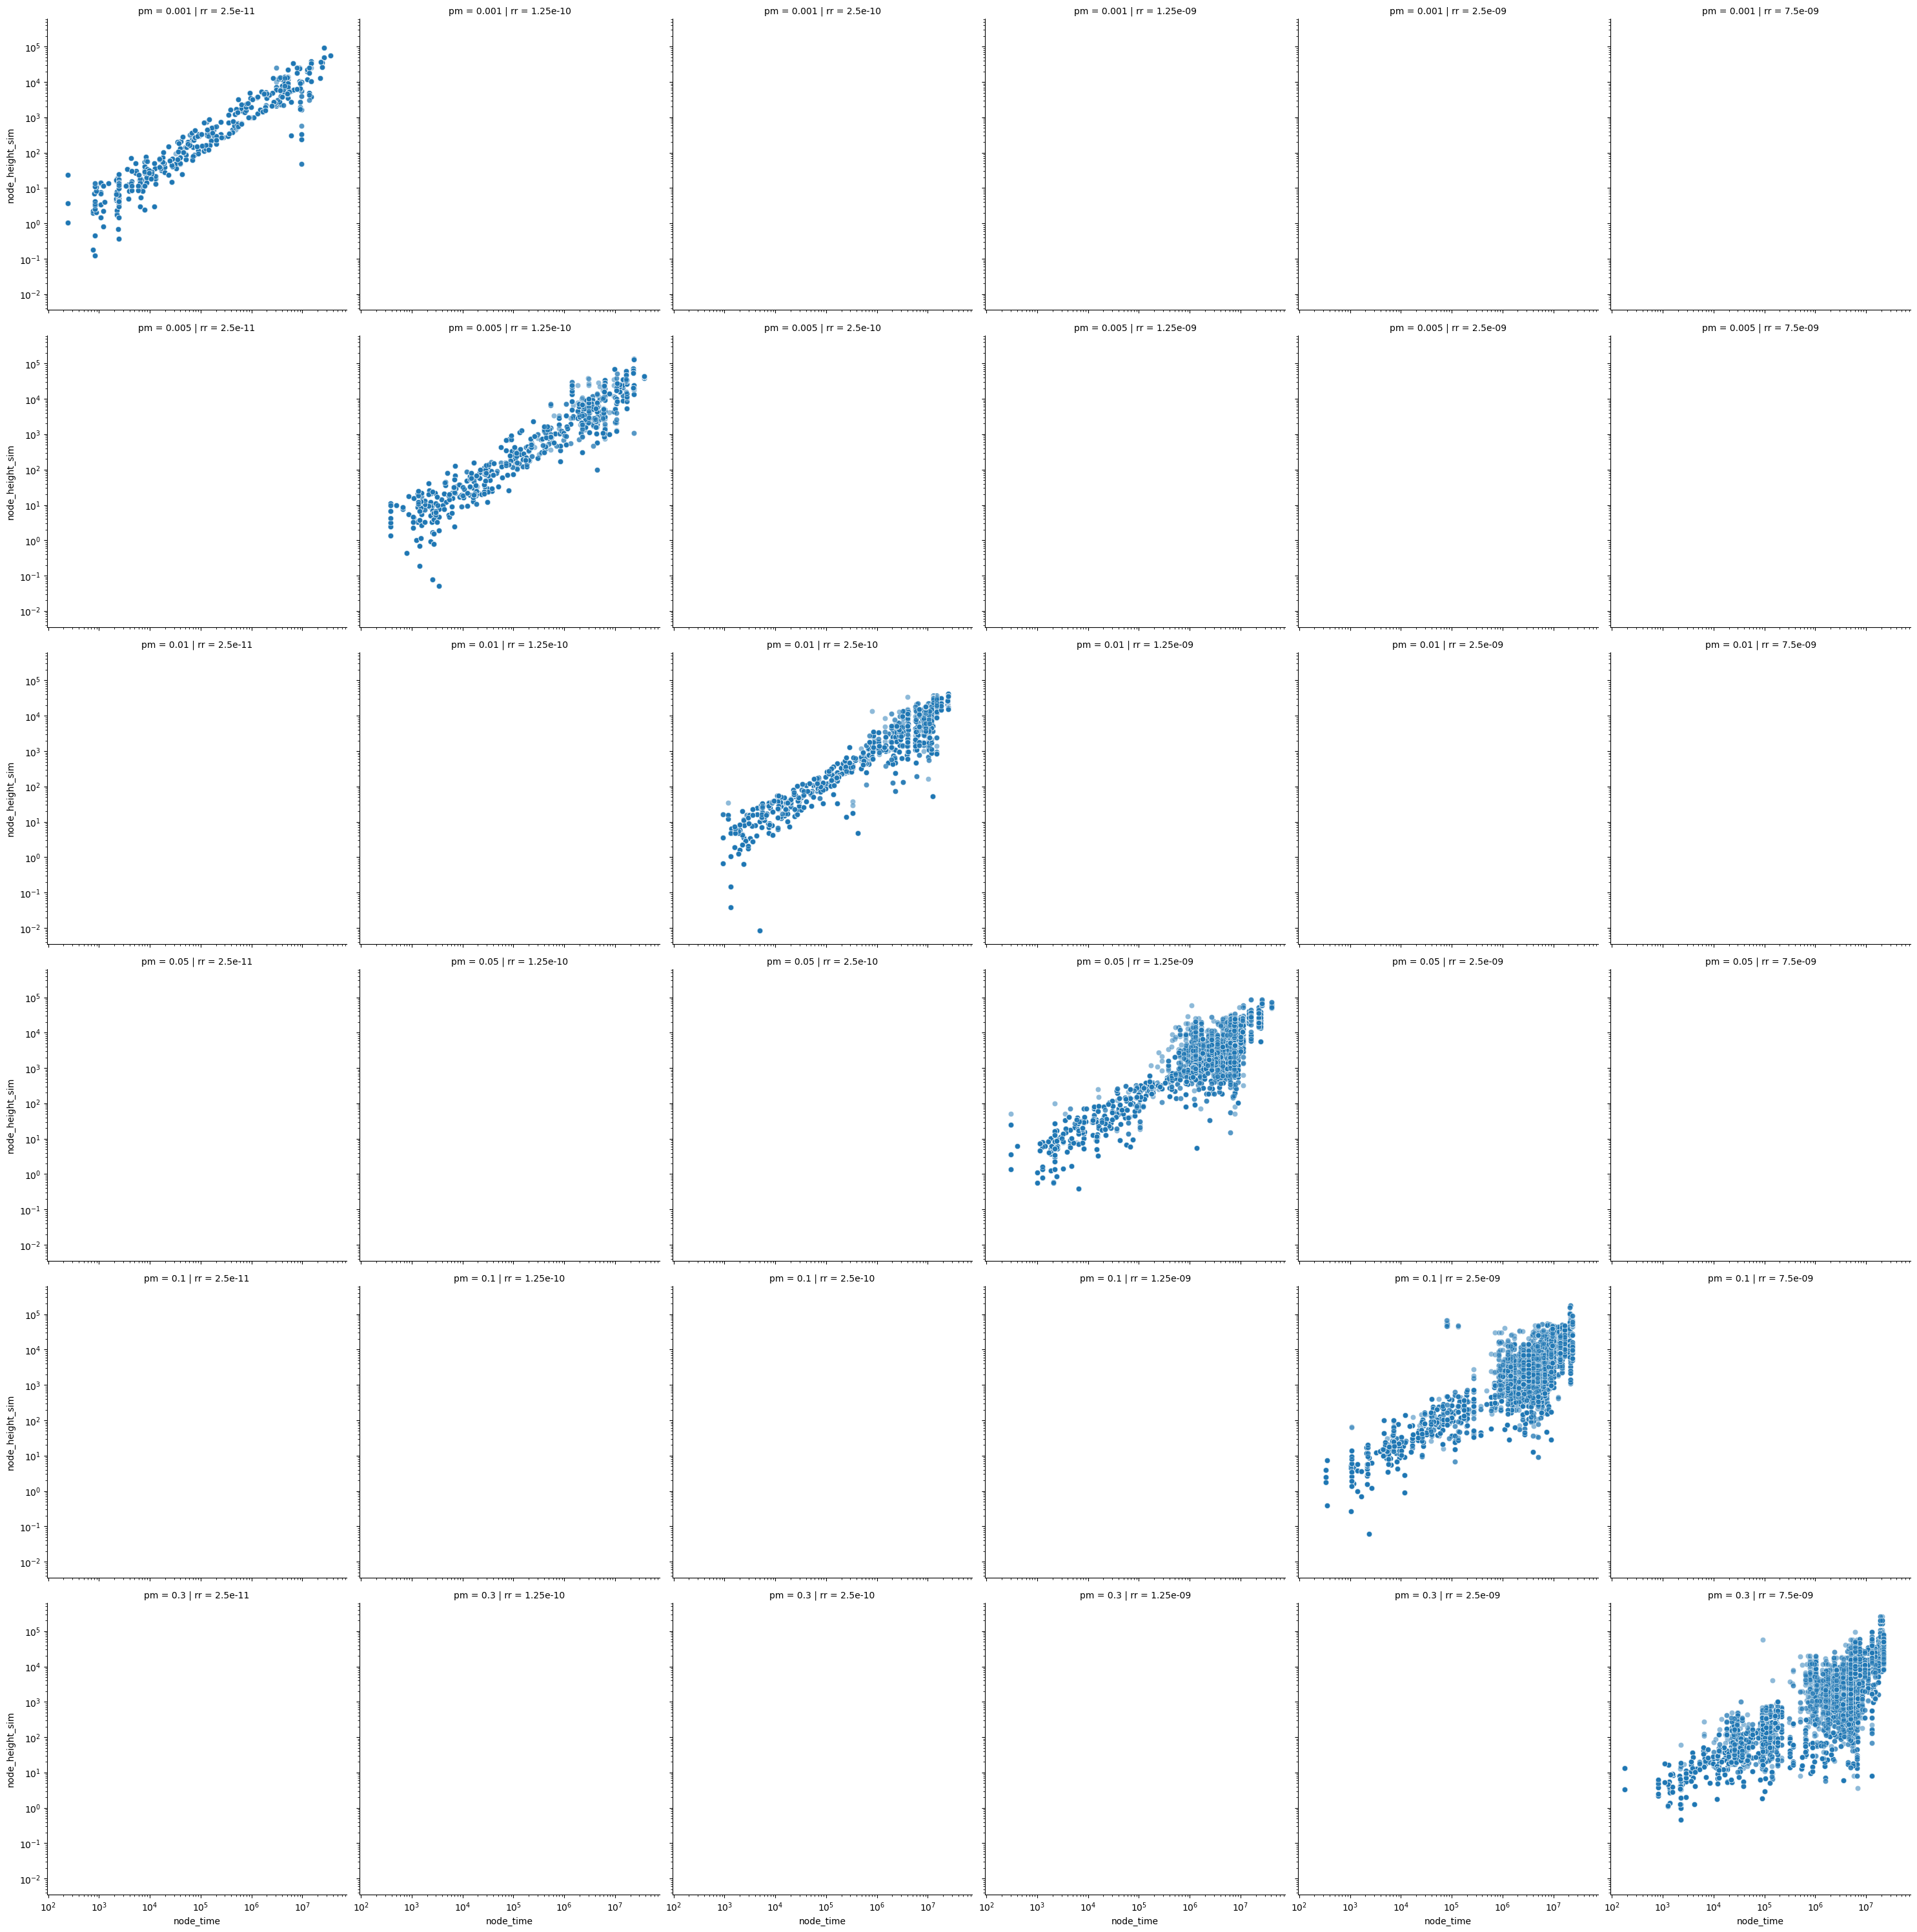

In [131]:
import seaborn as sns


# Create the faceted scatter plot
g = sns.relplot(
    data=ctrl_s, 
    x="node_time", 
    y="node_height_sim", 
    col="rr",      # Creates a column for each 'rr' value
    row="pm",      # Creates a row for each 'pm' value
    kind="scatter",
    alpha=0.5
)

# Optional: Apply log scales if the data is exponential
g.set(xscale="log", yscale="log", )

plt.show()

In [ ]:


g = sns.relplot(
    data=ctrl_s, 
    x="node_time", 
    y="node_height_sim", 
    col="rr",      
    row="pm",      
    kind="scatter",
    alpha=0.5,
    hue = 'seed' 
)


g.set(xscale="log", yscale="log", )

plt.show()

In [137]:
ctrl_s[(ctrl_s['pm'] == 0.3) & (ctrl_s['mr'] == 0.0001)]['seed'].unique()

array(['302', '307', '312'], dtype=object)

In [144]:
# get run count so i don't have to use seed 
ctrl_s['pm_mr'] = "PM: " + ctrl_s['pm'].astype(str) + " | RR: " + ctrl_s['mr'].astype(str)


ctrl_s['run_index'] = (
    ctrl_s.groupby(['pm_mr', 'seed'], sort=True).ngroup() 
    .groupby(ctrl_s['pm_mr']).rank(method='dense').astype(int) 
    .map({1: 'rep1', 2: 'rep2', 3: 'rep3'})
)

/loc/scratch/51884484/ipykernel_28319/3640647398.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctrl_s['pm_mr'] = "PM: " + ctrl_s['pm'].astype(str) + " | RR: " + ctrl_s['mr'].astype(str)
/loc/scratch/51884484/ipykernel_28319/3640647398.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctrl_s['run_index'] = (


In [ ]:
ctrl_s['mr'] = ctrl_s['mr'].astype(float) 
sorted_pm = sorted(ctrl_s['pm'].unique())
sorted_mr = sorted(ctrl_s['mr'].unique())

/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


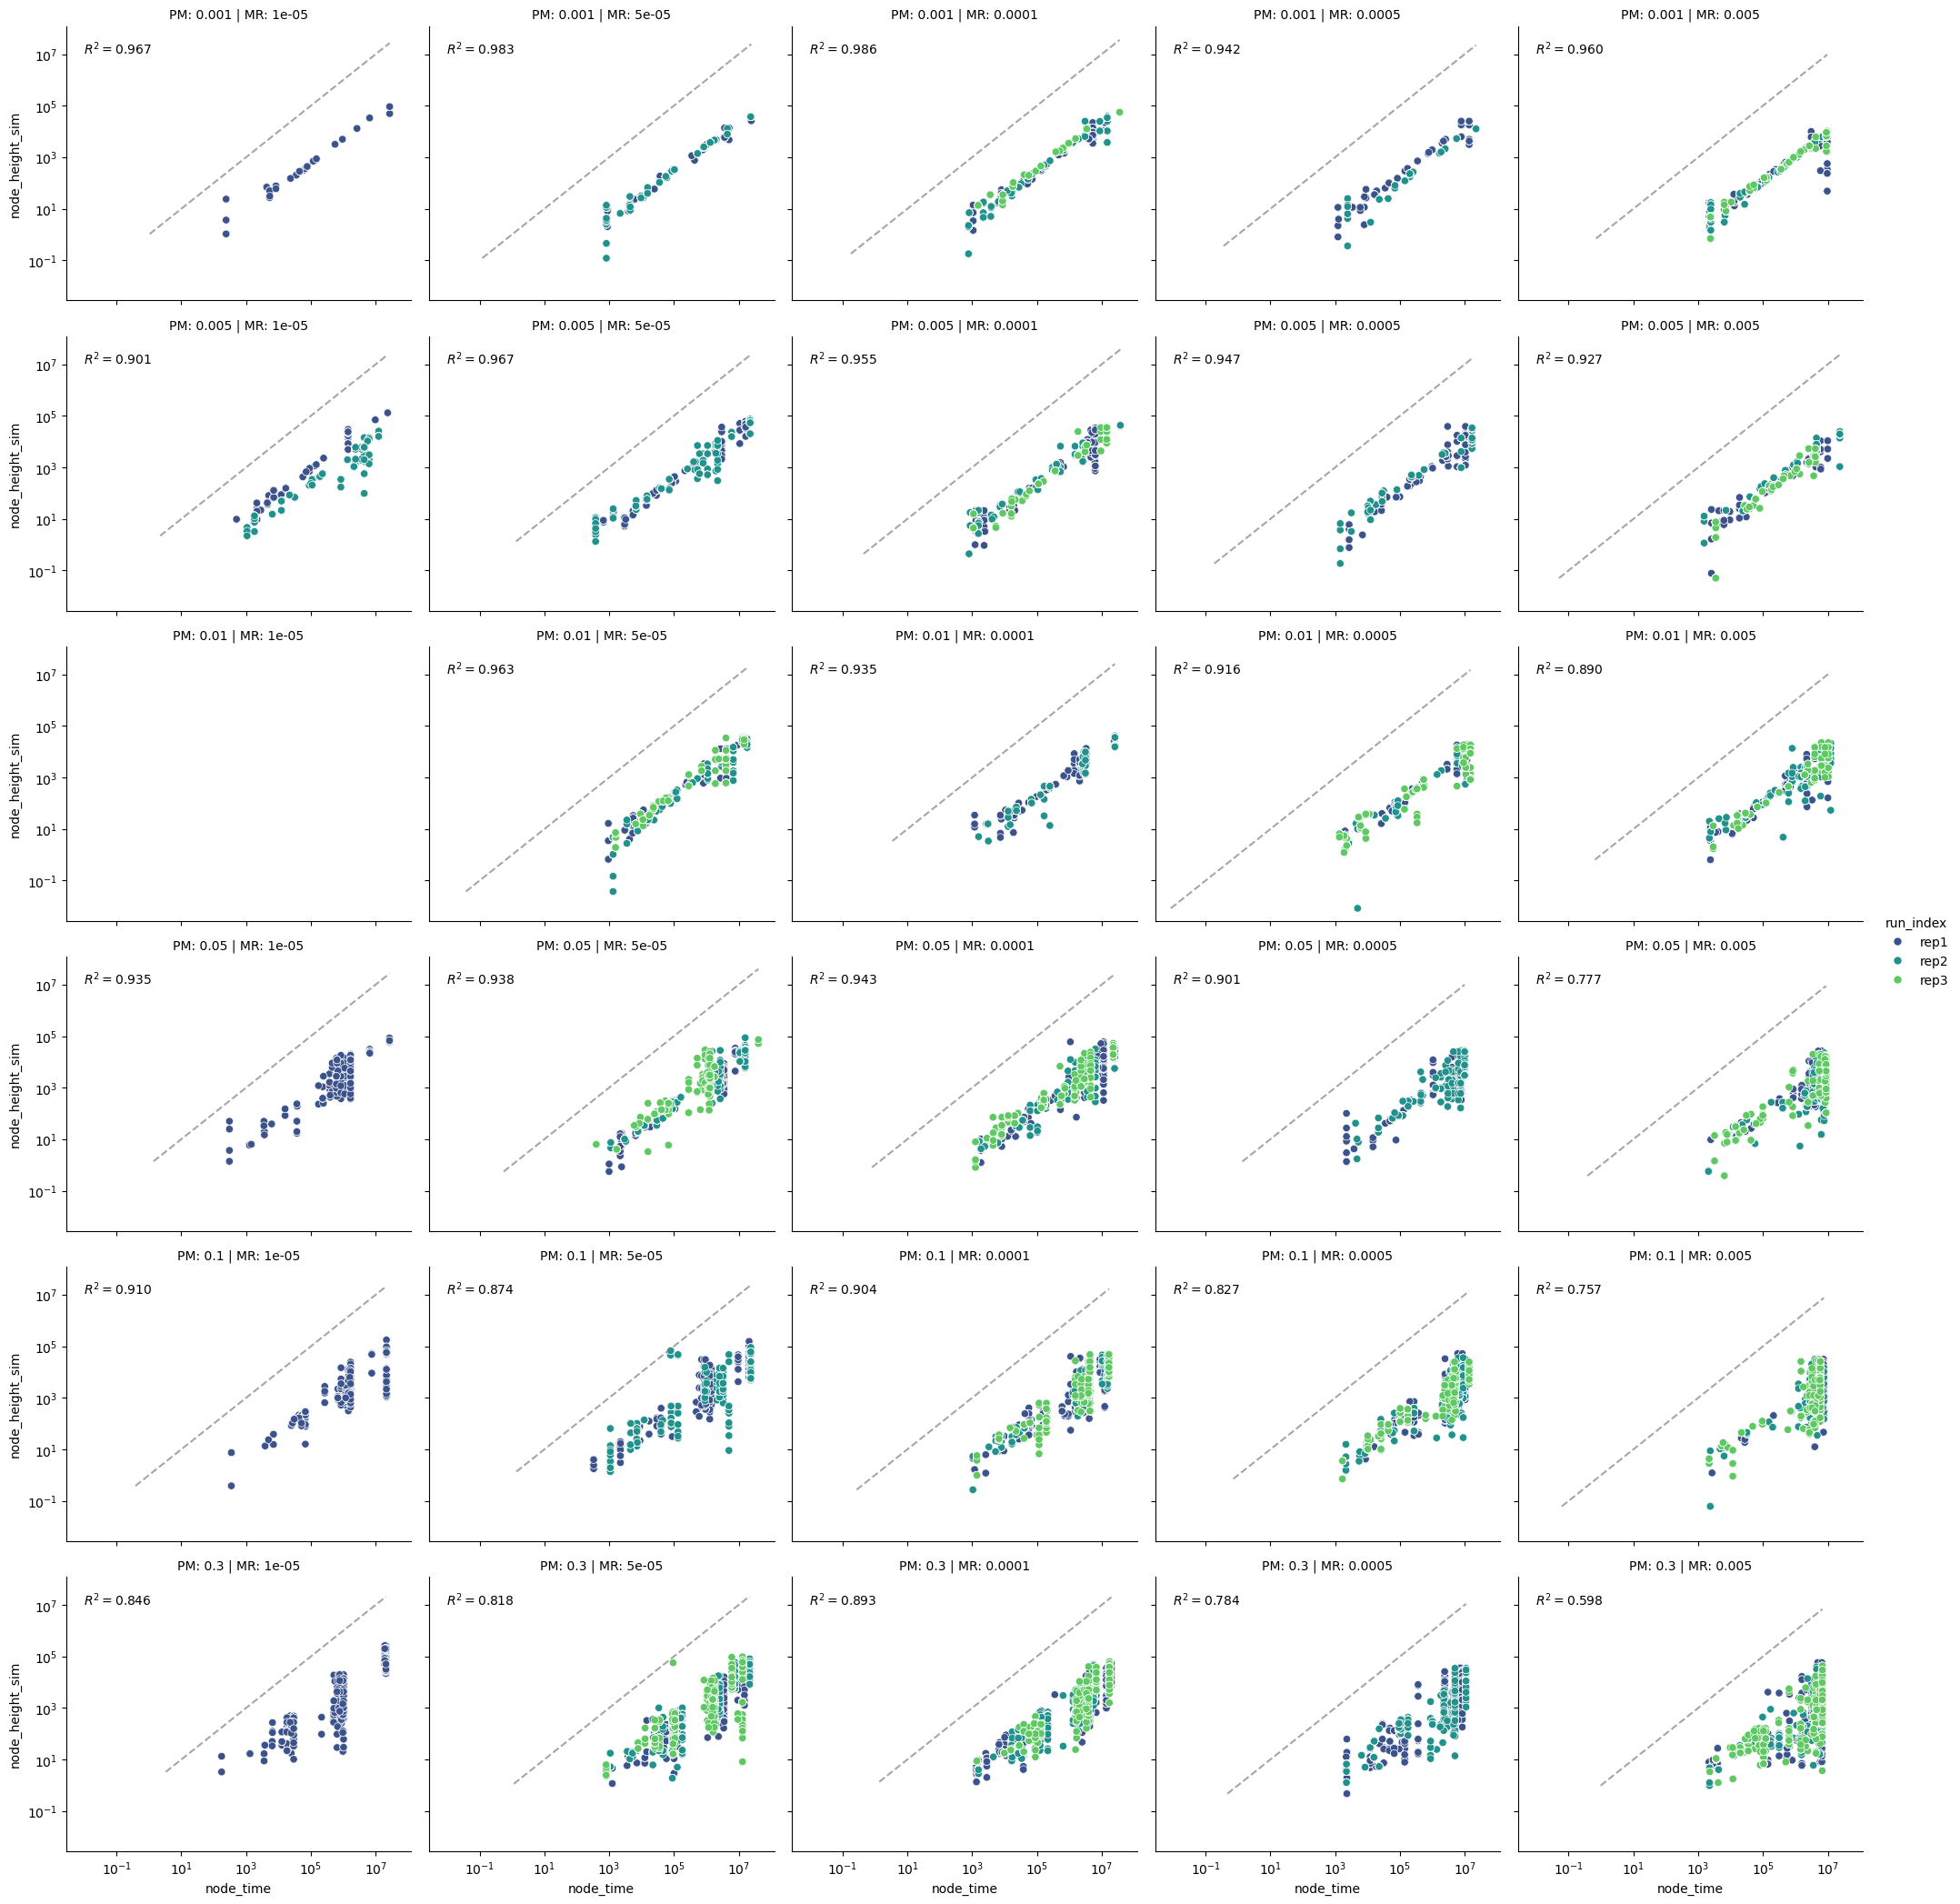

In [153]:
g = sns.relplot(
    data=ctrl_s, 
    x="node_time", y="node_height_sim", 
    hue="run_index", 
    row="pm", row_order=sorted_pm, 
    col="mr", col_order=sorted_mr, 
    kind="scatter",
    height=3.5, aspect=1.2, palette="viridis"
)


for (row_val, col_val), ax in g.axes_dict.items():

    subset = ctrl_s[(ctrl_s['pm'] == row_val) & (ctrl_s['mr'] == col_val)]
    
    if not subset.empty:
        
        low = min(subset['node_time'].min(), subset['node_height_sim'].min())
        high = max(subset['node_time'].max(), subset['node_height_sim'].max())
        ax.plot([low, high], [low, high], color='grey', linestyle='--', alpha=0.7, label='x=y')

        # annotate w/ r2 value [pooled reps]
        r2 = r2_log1p(subset['node_time'], subset['node_height_sim'])
        ax.text(0.05, 0.95, f'$R^2 = {r2:.3f}$', 
                transform=ax.transAxes, verticalalignment='top')

# Final formatting
g.set(xscale="log", yscale="log")
g.set_titles(row_template="PM: {row_name}", col_template="MR: {col_name}")

plt.show()

/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


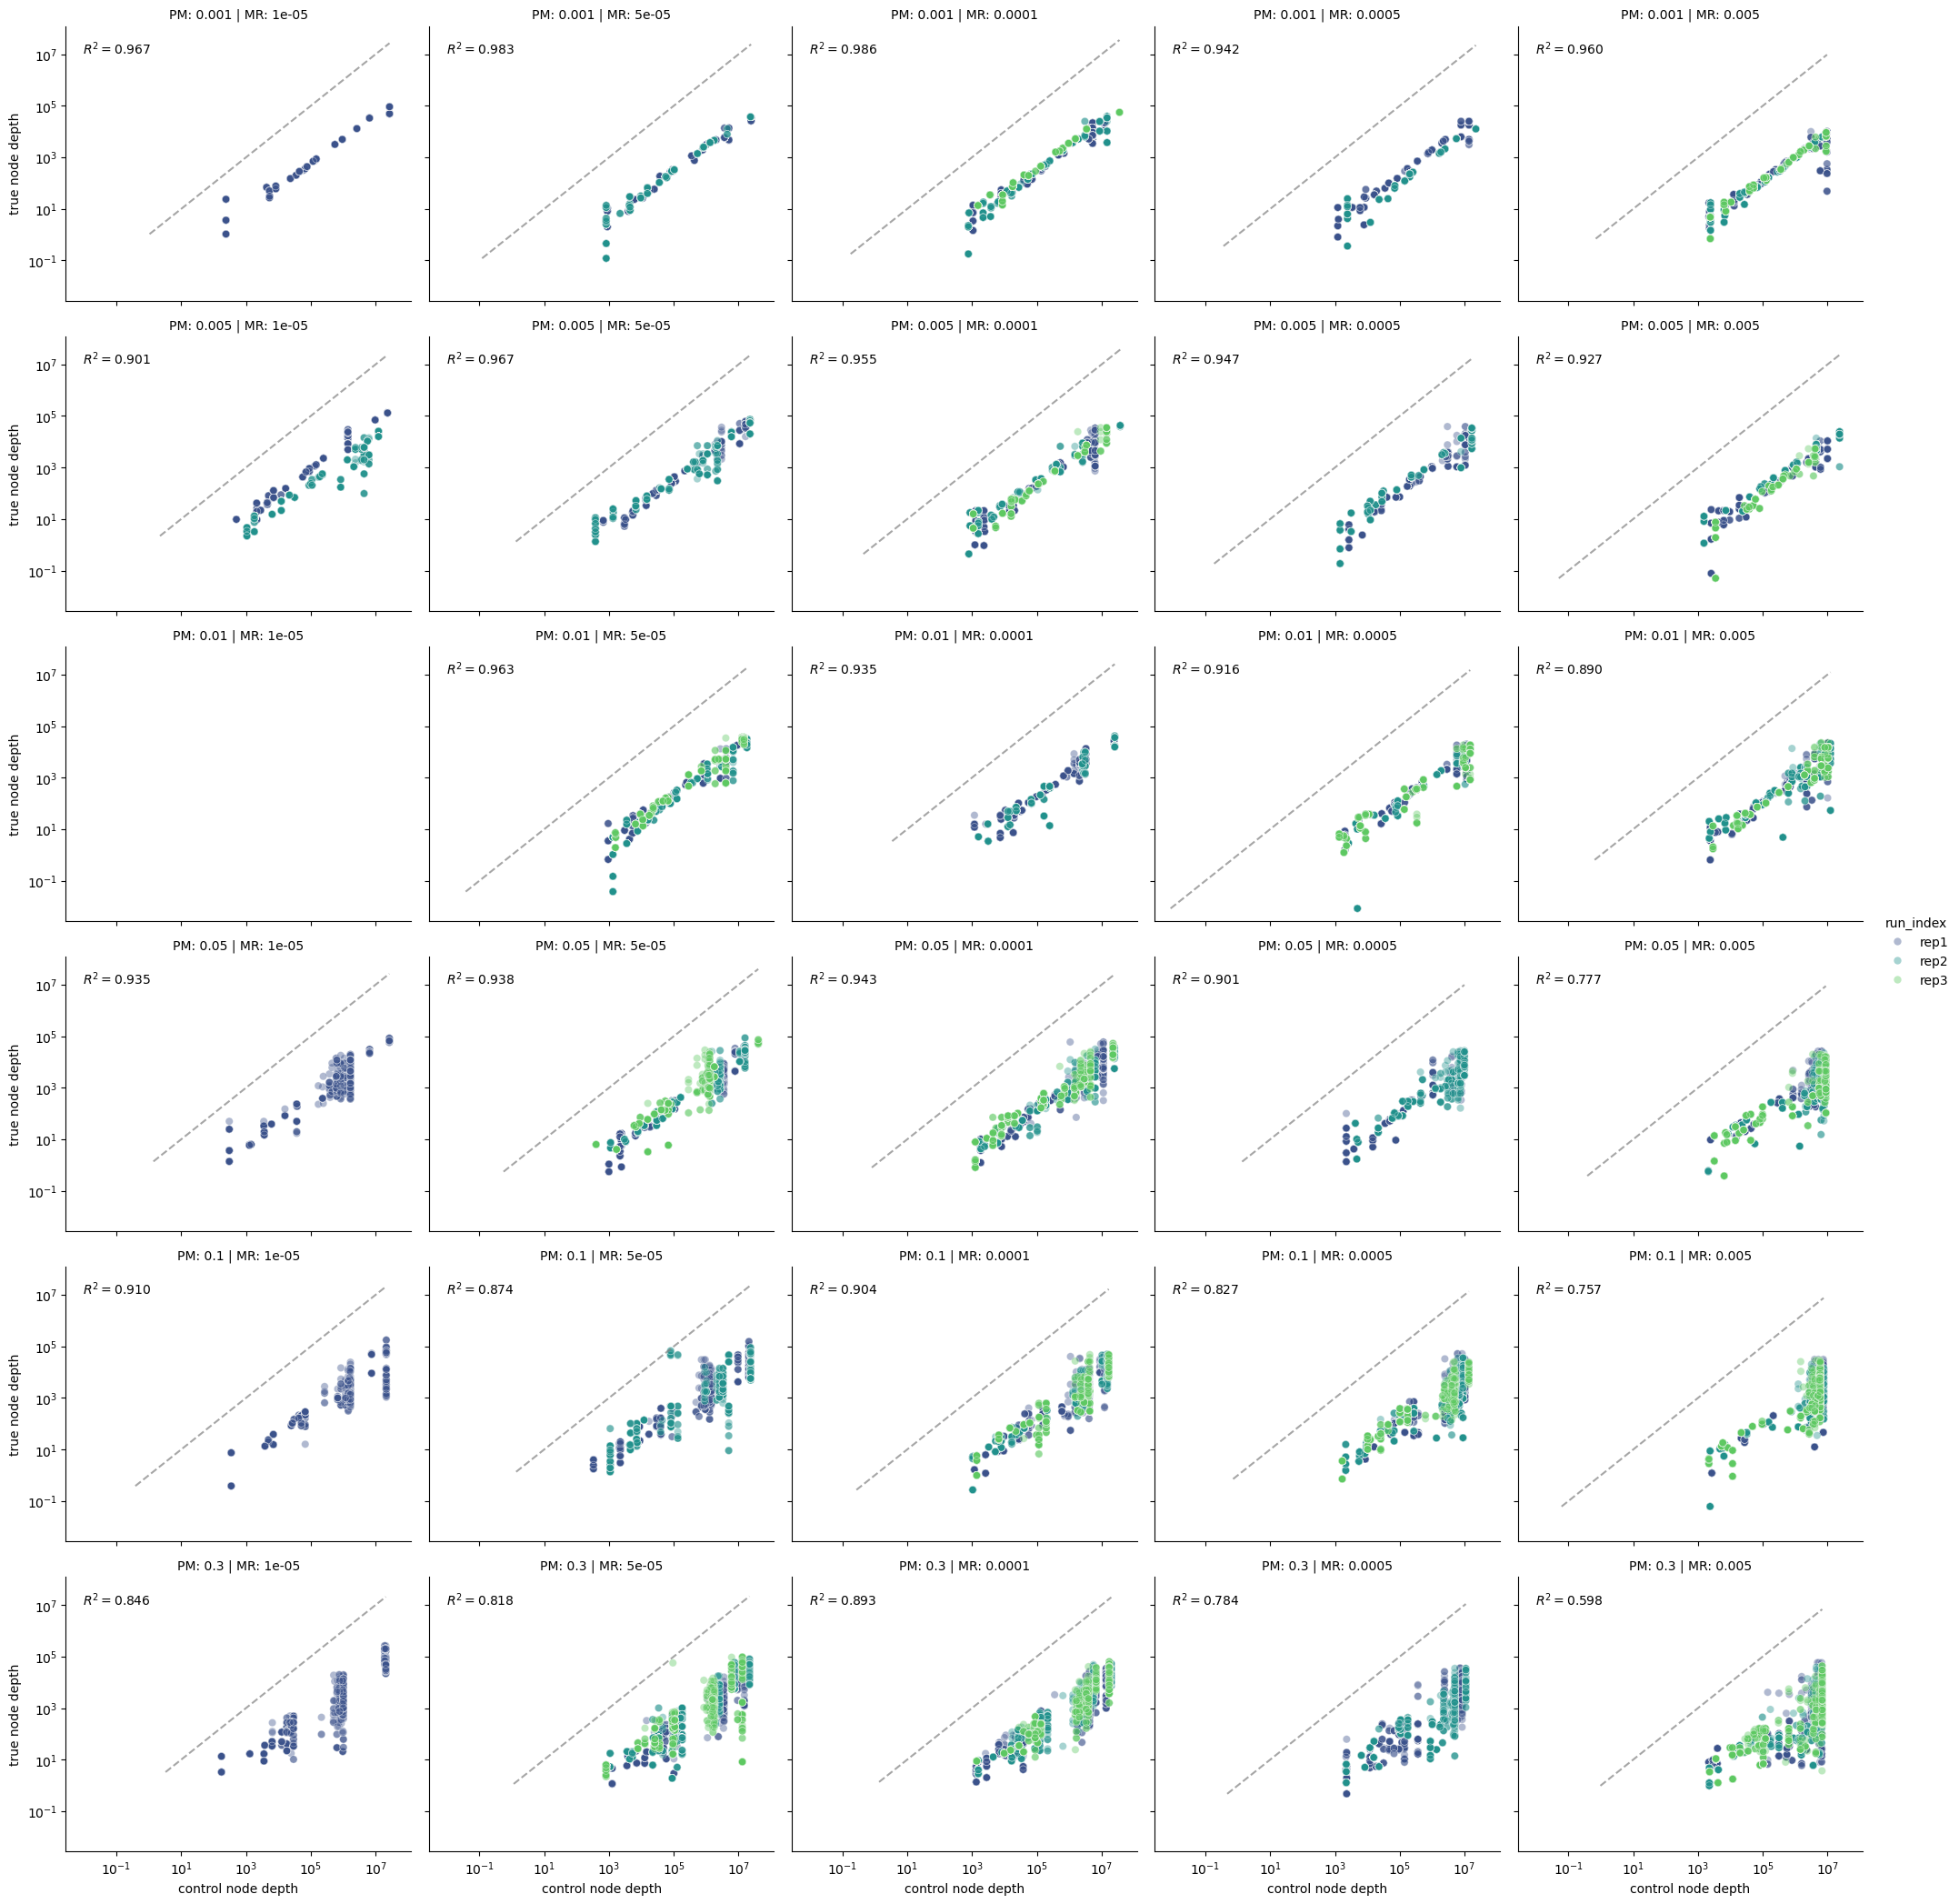

In [155]:
g = sns.relplot(
    data=ctrl_s, 
    x="node_time", y="node_height_sim",
    hue="run_index", 
    row="pm", row_order=sorted_pm, 
    col="mr", col_order=sorted_mr, 
    kind="scatter",
    height=3.5, 
    aspect=1.2, 
    palette="viridis",
    alpha = 0.4
)


for (row_val, col_val), ax in g.axes_dict.items():

    subset = ctrl_s[(ctrl_s['pm'] == row_val) & (ctrl_s['mr'] == col_val)]
    
    if not subset.empty:
        
        low = min(subset['node_time'].min(), subset['node_height_sim'].min())
        high = max(subset['node_time'].max(), subset['node_height_sim'].max())
        ax.plot([low, high], [low, high], color='grey', linestyle='--', alpha=0.7, label='x=y')

        # annotate w/ r2 value [pooled reps]
        r2 = r2_log1p(subset['node_time'], subset['node_height_sim'])
        ax.text(0.05, 0.95, f'$R^2 = {r2:.3f}$', 
                transform=ax.transAxes, verticalalignment='top')

# Final formatting
g.set(xscale="log", yscale="log")
g.set_titles(row_template="PM: {row_name}", col_template="MR: {col_name}")
g.set_axis_labels("control node depth", "true node depth")

plt.show()

### inf_height vs sim_height

In [157]:
# get run count so i don't have to use seed 
inf_s['pm_mr'] = "PM: " + inf_s['pm'].astype(str) + " | RR: " + inf_s['mr'].astype(str)


inf_s['run_index'] = (
    inf_s.groupby(['pm_mr', 'seed'], sort=True).ngroup() 
    .groupby(inf_s['pm_mr']).rank(method='dense').astype(int) 
    .map({1: 'rep1', 2: 'rep2', 3: 'rep3'})
)

/loc/scratch/51884484/ipykernel_28319/1046705853.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inf_s['pm_mr'] = "PM: " + inf_s['pm'].astype(str) + " | RR: " + inf_s['mr'].astype(str)
/loc/scratch/51884484/ipykernel_28319/1046705853.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inf_s['run_index'] = (


/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


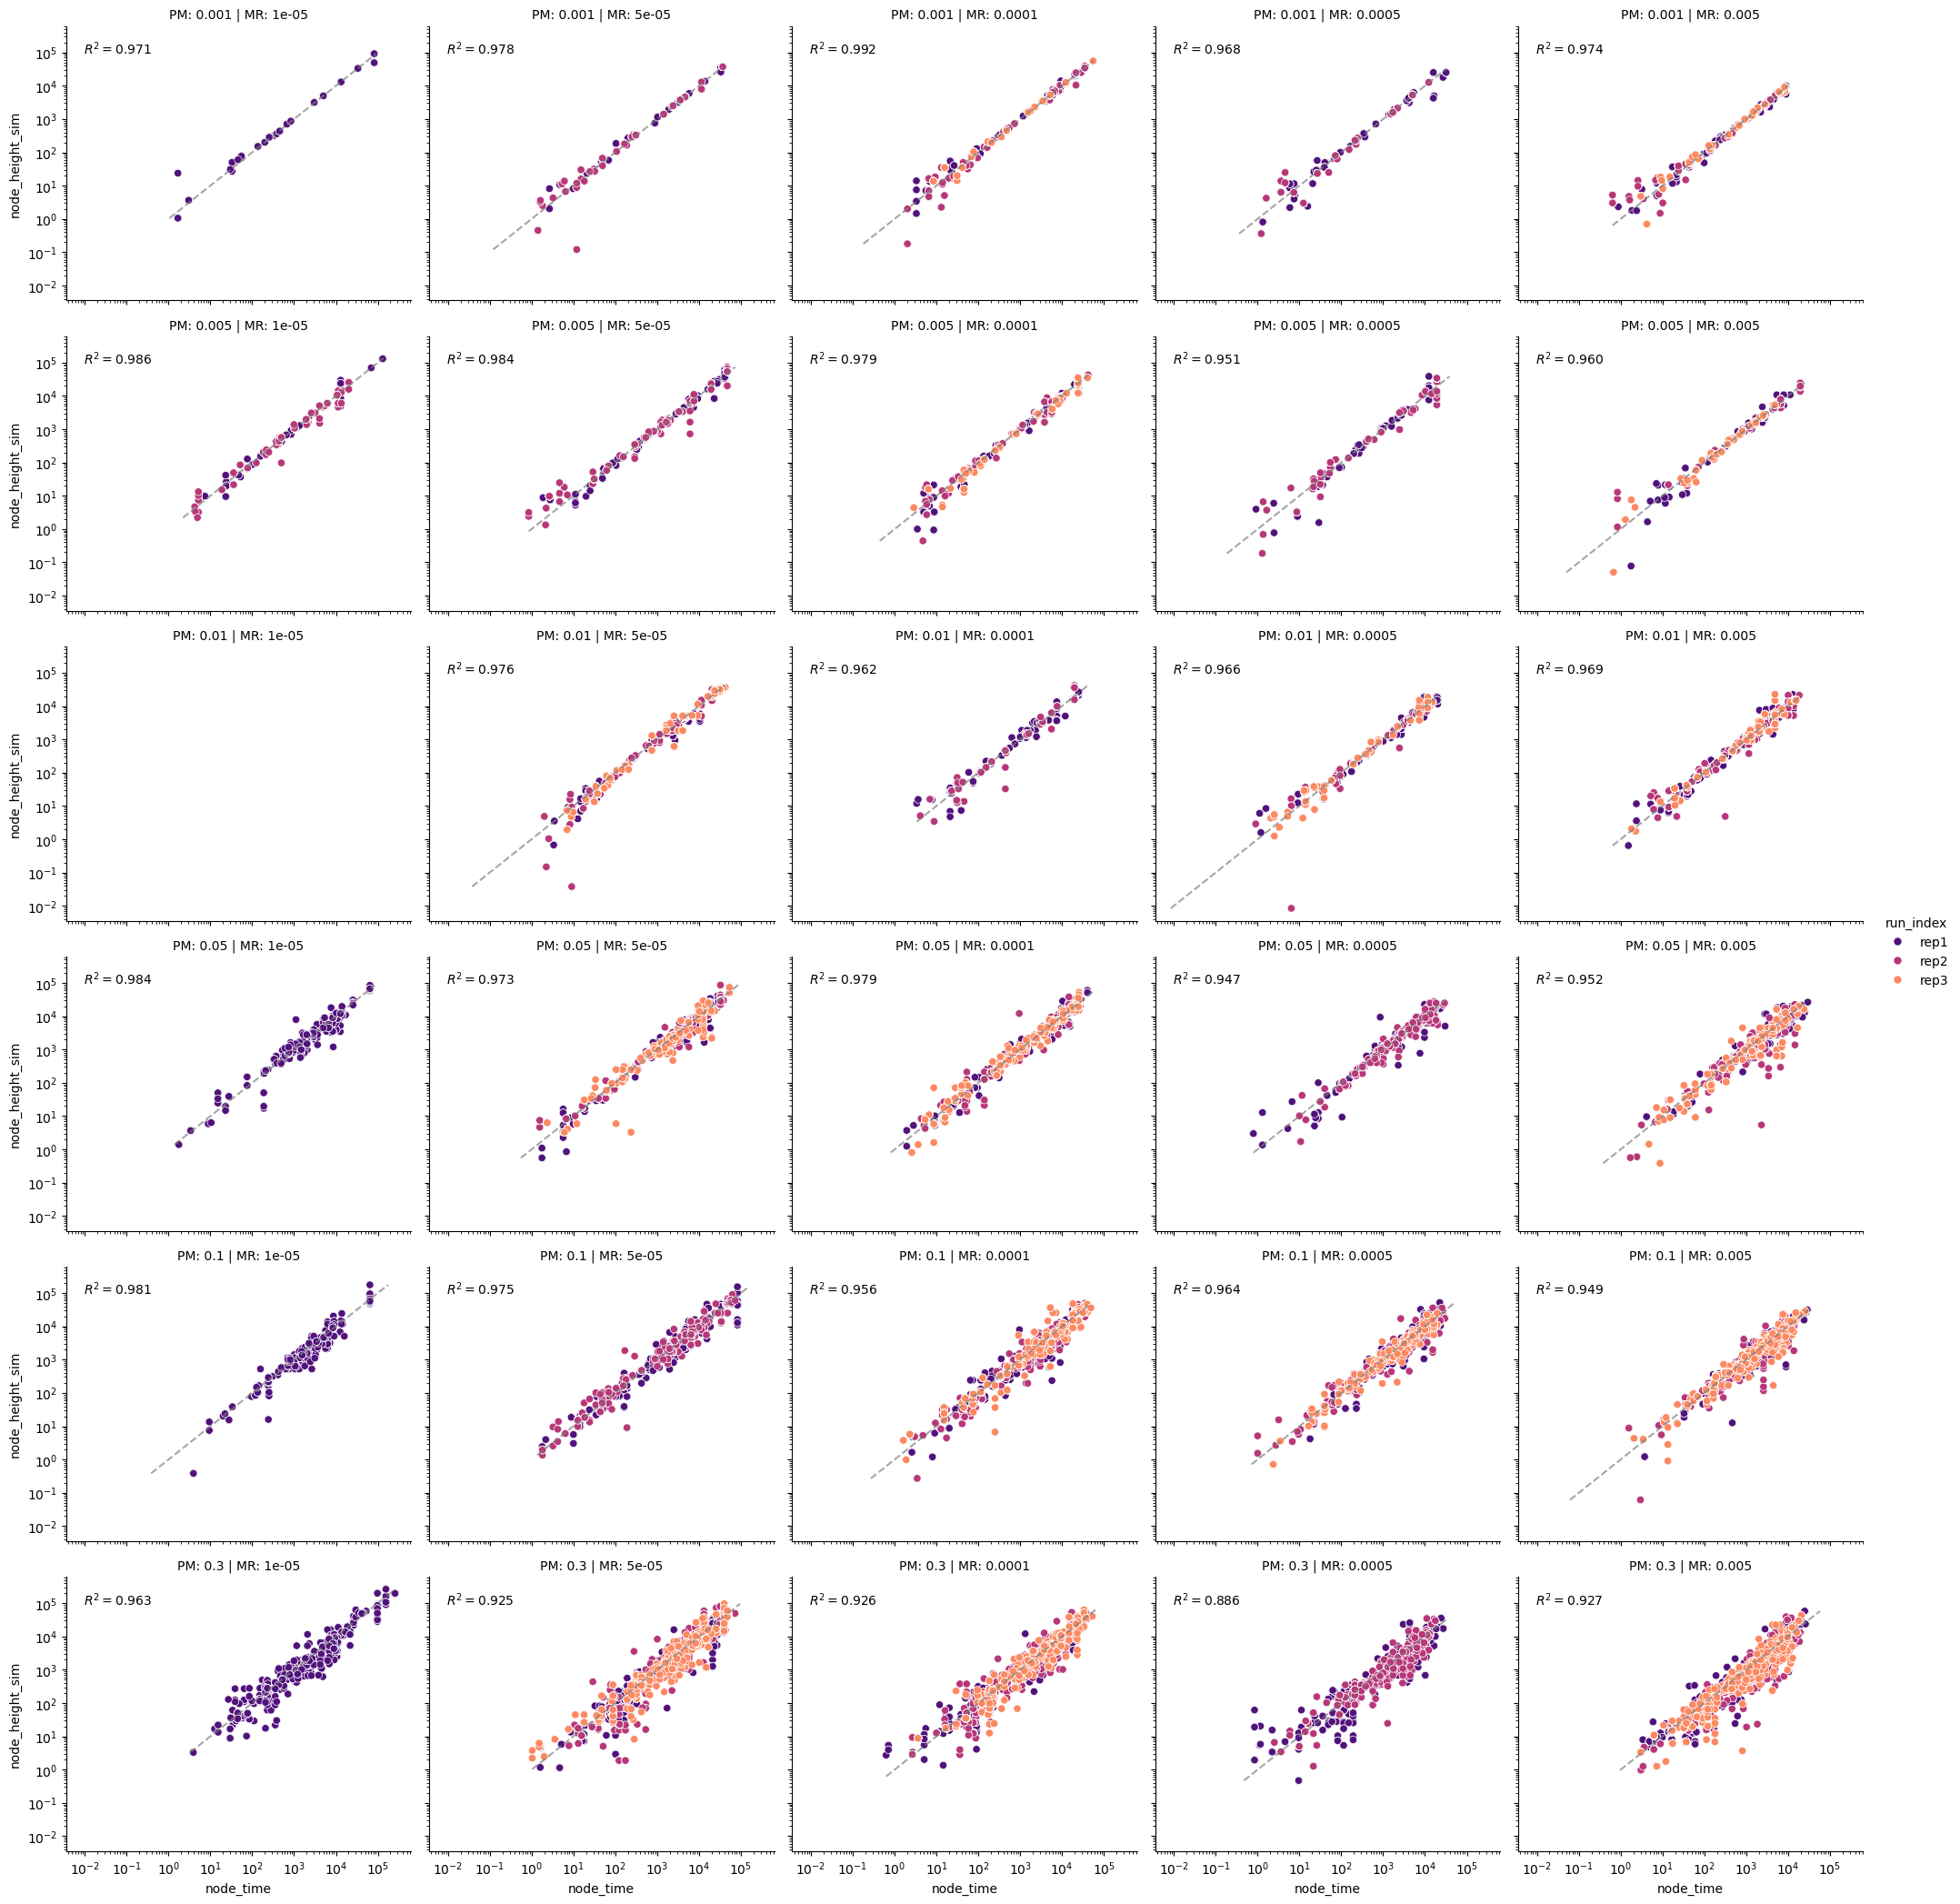

In [159]:
g = sns.relplot(
    data=inf_s, 
    x="node_time", y="node_height_sim", 
    hue="run_index", 
    row="pm", row_order=sorted_pm, 
    col="mr", col_order=sorted_mr, 
    kind="scatter",
    height=3.5, aspect=1.2, palette="magma"
)


for (row_val, col_val), ax in g.axes_dict.items():

    subset = inf_s[(inf_s['pm'] == row_val) & (inf_s['mr'] == col_val)]
    
    if not subset.empty:
        
        low = min(subset['node_time'].min(), subset['node_height_sim'].min())
        high = max(subset['node_time'].max(), subset['node_height_sim'].max())
        ax.plot([low, high], [low, high], color='grey', linestyle='--', alpha=0.7, label='x=y')

        # annotate w/ r2 value [pooled reps]
        r2 = r2_log1p(subset['node_time'], subset['node_height_sim'])
        ax.text(0.05, 0.95, f'$R^2 = {r2:.3f}$', 
                transform=ax.transAxes, verticalalignment='top')

# Final formatting
g.set(xscale="log", yscale="log")
g.set_titles(row_template="PM: {row_name}", col_template="MR: {col_name}")

plt.show()

In [131]:
bp_colors[3]

(0.47936222, 0.18006056, 0.43733022)

In [ ]:
inf_c = inf_s[inf_s['mu'] == 1e-8]
null_c = null_s[null_s['mu'] == 1e-8]

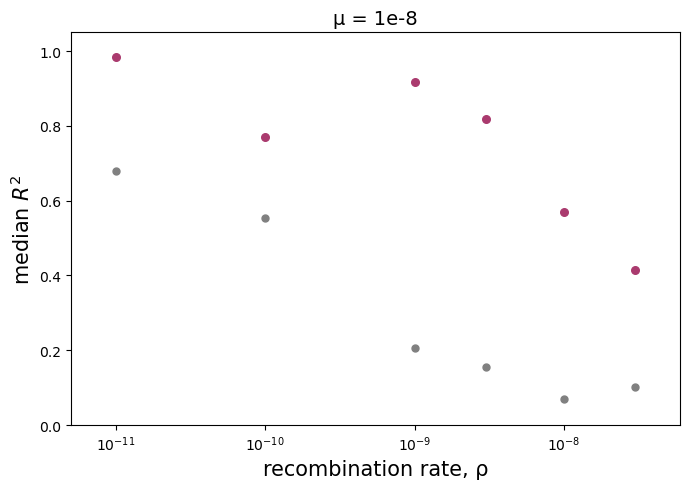

In [168]:
fig, ax = plt.subplots(figsize=(7, 5))

# colormap for different pm values
cmap = plt.get_cmap("mako")
pm_values = [0.001, 0.01, 0.1, 0.3, 1.0, 3.0]
colors = cmap(np.linspace(0, 1, len(pm_values)))

# aggregate so theres 1 row per (pm, rr) combo
inf_c = inf_s[inf_s['mu'] == 1e-8]
null_c = null_s[null_s['mu'] == 1e-8]

inf_fit = (inf_c.groupby(["pm", "rr"], as_index=False).agg(median_r2=("median_r2", "median")))

null_fit = (null_c.groupby(["pm", "rr"], as_index=False).agg(median_r2=("median_r2", "median")))


# plot per pm 
for pm, color in zip(pm_values, colors):
    # inferred
    sub_i = inf_fit[np.isclose(inf_fit["pm"], pm)]
    if len(sub_i):
        ax.scatter(
            sub_i["rr"], sub_i["median_r2"],
            s=30, alpha=1, color=bp_colors[2],
            label=f"ρ/μ={pm:g}"
        )
        if len(sub_i) >= 2:
            lx = np.log(sub_i["rr"].to_numpy())
            y = sub_i["median_r2"].to_numpy()
            m, b = np.polyfit(lx, y, 1)
            log_x = np.linspace(lx.min(), lx.max(), 200)
            ax.plot(np.exp(log_x), m * log_x + b, color=color, lw=2)

    # null (same color, lower alpha)
    sub_n = null_fit[np.isclose(null_fit["pm"], pm)]
    if len(sub_n):
        ax.scatter(
            sub_n["rr"], sub_n["median_r2"],
            s=25, alpha=1, color='grey'#,
           # label=f"null ρ/μ={pm:g}"
        )

    # if len(null_all):
    #     ax.scatter(
    #         null_s["rr"], null_s["median_r2"],
    #         s=12, alpha=0.75, c="lightgrey", label="null (permuted bins)"
    #     )
        # if len(sub_n) >= 2:
        #     lx = np.log(sub_n["rr"].to_numpy())
        #     y = sub_n["median_r2"].to_numpy()
        #     m, b = np.polyfit(lx, y, 1)
        #     log_x = np.linspace(lx.min(), lx.max(), 200)
        #     ax.plot(np.exp(log_x), m * log_x + b, color=color, lw=1, ls="--", alpha=0.35)

# fmt axes
ax.set_xscale("log")
ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.set_ylim(0, 1.05)

# x limits from inferred, else use null
all_rr = inf_fit["rr"] if len(inf_fit) else null_fit["rr"]
ax.set_xlim(all_rr.min() * 0.5, all_rr.max() * 2.0)

ax.set_xlabel("recombination rate, ρ", fontsize=15)
ax.set_ylabel("median $R^2$", fontsize=15)

plt.title("μ = 1e-8", fontsize = 14)
#ax.legend(frameon=False, fontsize=12, loc="lower left", ncol=1)

fig.tight_layout()
#plt.savefig("figure_c.png")
plt.show()


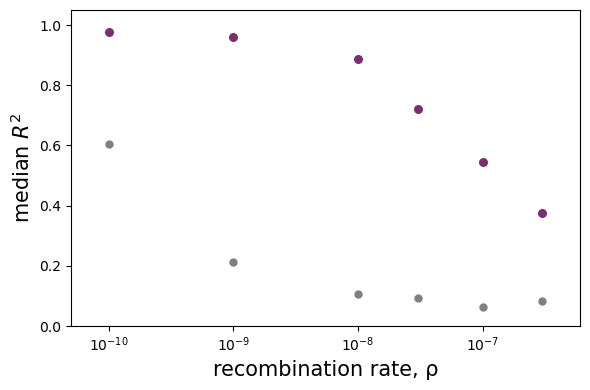

In [169]:
fig, ax = plt.subplots(figsize=(6, 4))

# colormap for different pm values
cmap = plt.get_cmap("mako")
pm_values = [0.001, 0.01, 0.1, 0.3, 1.0, 3.0]
colors = cmap(np.linspace(0, 1, len(pm_values)))

# aggregate so theres 1 row per (pm, rr) combo
inf_c = inf_s[inf_s['mu'] == 1e-7]
null_c = null_s[null_s['mu'] == 1e-7]

inf_fit = (inf_c.groupby(["pm", "rr"], as_index=False).agg(median_r2=("median_r2", "median")))

null_fit = (null_c.groupby(["pm", "rr"], as_index=False).agg(median_r2=("median_r2", "median")))


# plot per pm 
for pm, color in zip(pm_values, colors):


     # discrete mapping b/w rr and avg_breakpoints 
    bp_map = (
        inf_c[["rr", "avg_breakpoints"]]
        .dropna()
        .drop_duplicates(subset=["rr"])
        .sort_values("rr")
    )
    rr_ticks = bp_map["rr"].to_numpy()
    bp_labels = bp_map["avg_breakpoints"].to_numpy()

    
    # inferred
    sub_i = inf_fit[np.isclose(inf_fit["pm"], pm)]
    if len(sub_i):
        ax.scatter(
            sub_i["rr"], sub_i["median_r2"],
            s=30, alpha=1, color=bp_colors[3],
            label=f"ρ/μ={pm:g}"
        )
        # if len(sub_i) >= 2:
        #     lx = np.log(sub_i["rr"].to_numpy())
        #     y = sub_i["median_r2"].to_numpy()
        #     m, b = np.polyfit(lx, y, 1)
        #     log_x = np.linspace(lx.min(), lx.max(), 200)
        #     ax.plot(np.exp(log_x), m * log_x + b, color=color, lw=2)

    # null (same color, lower alpha)
    sub_n = null_fit[np.isclose(null_fit["pm"], pm)]
    if len(sub_n):
        ax.scatter(
            sub_n["rr"], sub_n["median_r2"],
            s=25, alpha=1, color='grey'#,
           # label=f"null ρ/μ={pm:g}"
        )


        # x axis showing just discrete breakpoints 
    ax.set_xscale("log")
    ax.xaxis.set_minor_locator(ticker.NullLocator())

    if len(rr_ticks):
        max_labels = 5  # tweak for clutter
        if len(rr_ticks) > max_labels:
            keep = np.linspace(0, len(rr_ticks) - 1, max_labels, dtype=int)
            rr_ticks_show = rr_ticks[keep]
            bp_labels_show = bp_labels[keep]
        else:
            rr_ticks_show = rr_ticks
            bp_labels_show = bp_labels

        ax.set_xticks(rr_ticks_show)
        ax.set_xticklabels([f"{b:g}" for b in bp_labels_show])

    # if len(null_all):
    #     ax.scatter(
    #         null_s["rr"], null_s["median_r2"],
    #         s=12, alpha=0.75, c="lightgrey", label="null (permuted bins)"
    #     )
        # if len(sub_n) >= 2:
        #     lx = np.log(sub_n["rr"].to_numpy())
        #     y = sub_n["median_r2"].to_numpy()
        #     m, b = np.polyfit(lx, y, 1)
        #     log_x = np.linspace(lx.min(), lx.max(), 200)
        #     ax.plot(np.exp(log_x), m * log_x + b, color=color, lw=1, ls="--", alpha=0.35)

# fmt axes
ax.set_xscale("log")
ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.set_ylim(0, 1.05)

# x limits from inferred, else use null
all_rr = inf_fit["rr"] if len(inf_fit) else null_fit["rr"]
ax.set_xlim(all_rr.min() * 0.5, all_rr.max() * 2.0)

ax.set_xlabel("recombination rate, ρ", fontsize=15)
ax.set_ylabel("median $R^2$", fontsize=15)

#plt.title("μ = 1e-7", fontsize = 14)
#ax.legend(frameon=False, fontsize=12, loc="lower left", ncol=1)

fig.tight_layout()
#plt.savefig("figure_c_1e-7.png")
plt.show()
